# Cross-Country Climate Comparison: East Africa & Beyond
## Ethiopia, Kenya, Sudan, Tanzania, Nigeria (2015-2026)

In [11]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [12]:
# Load all datasets
countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
dfs = {}

for country in countries:
    try:
        # Try loading cleaned version if it exists
        df = pd.read_csv(f'../data/{country}_clean.csv')
        dfs[country] = df
        print(f"Loaded {country}_clean: {len(df)} rows")
    except FileNotFoundError:
        try:
            # Fallback to original version
            df = pd.read_csv(f'../data/{country}.csv')
            # Quick cleaning
            df = df.replace(-999, np.nan)
            # Add Country column if missing
            if 'Country' not in df.columns:
                df['Country'] = country.capitalize()
            dfs[country] = df
            print(f"Loaded {country} (original): {len(df)} rows")
        except FileNotFoundError:
            print(f"Error: No data found for {country}")

# Combine all dataframes
combined_df = pd.concat(dfs.values(), ignore_index=True)
print(f"\nCombined dataset shape: {combined_df.shape}")
print(f"Countries: {combined_df['Country'].unique()}")

Loaded ethiopia (original): 4108 rows
Loaded kenya (original): 4108 rows
Loaded sudan (original): 4108 rows
Loaded tanzania (original): 4108 rows
Loaded nigeria (original): 4108 rows

Combined dataset shape: (20540, 13)
Countries: ['Ethiopia' 'Kenya' 'Sudan' 'Tanzania' 'Nigeria']


In [13]:
# Ensure Date and temporal columns exist
if 'Date' not in combined_df.columns and 'YEAR' in combined_df.columns and 'DOY' in combined_df.columns:
    combined_df['Date'] = pd.to_datetime(
        combined_df['YEAR'].astype(str) + combined_df['DOY'].astype(str).str.zfill(3), 
        format='%Y%j'
    )

if 'Date' in combined_df.columns:
    combined_df['Year'] = combined_df['Date'].dt.year
    combined_df['Month'] = combined_df['Date'].dt.month
    combined_df['Month_Name'] = combined_df['Date'].dt.month_name()

## 1. Temperature Trend Comparison
Comparing monthly average temperatures across all five countries.

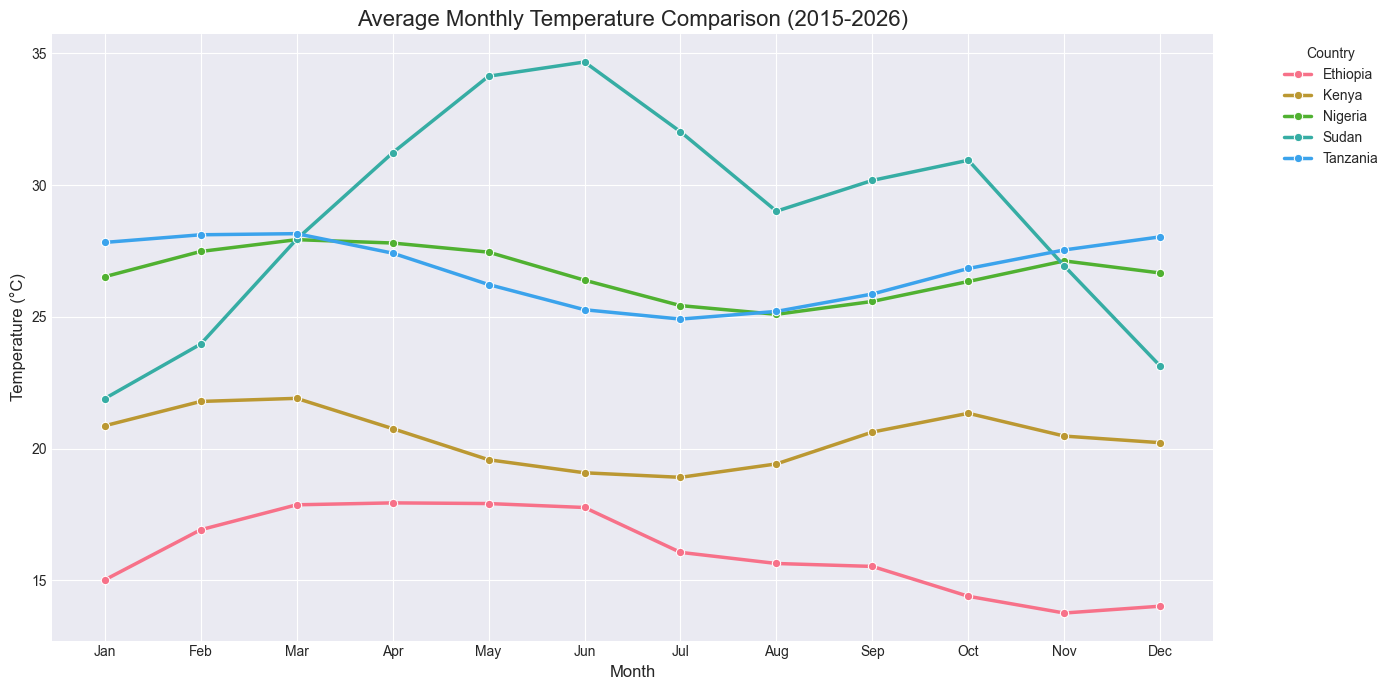

In [14]:
# Monthly average temperature by country
monthly_temp = combined_df.groupby(['Country', 'Month'])['T2M'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_temp, x='Month', y='T2M', hue='Country', marker='o', linewidth=2.5)
plt.title('Average Monthly Temperature Comparison (2015-2026)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Precipitation (Rainfall) Comparison
Analyzing rainfall patterns to understand regional rainy seasons.

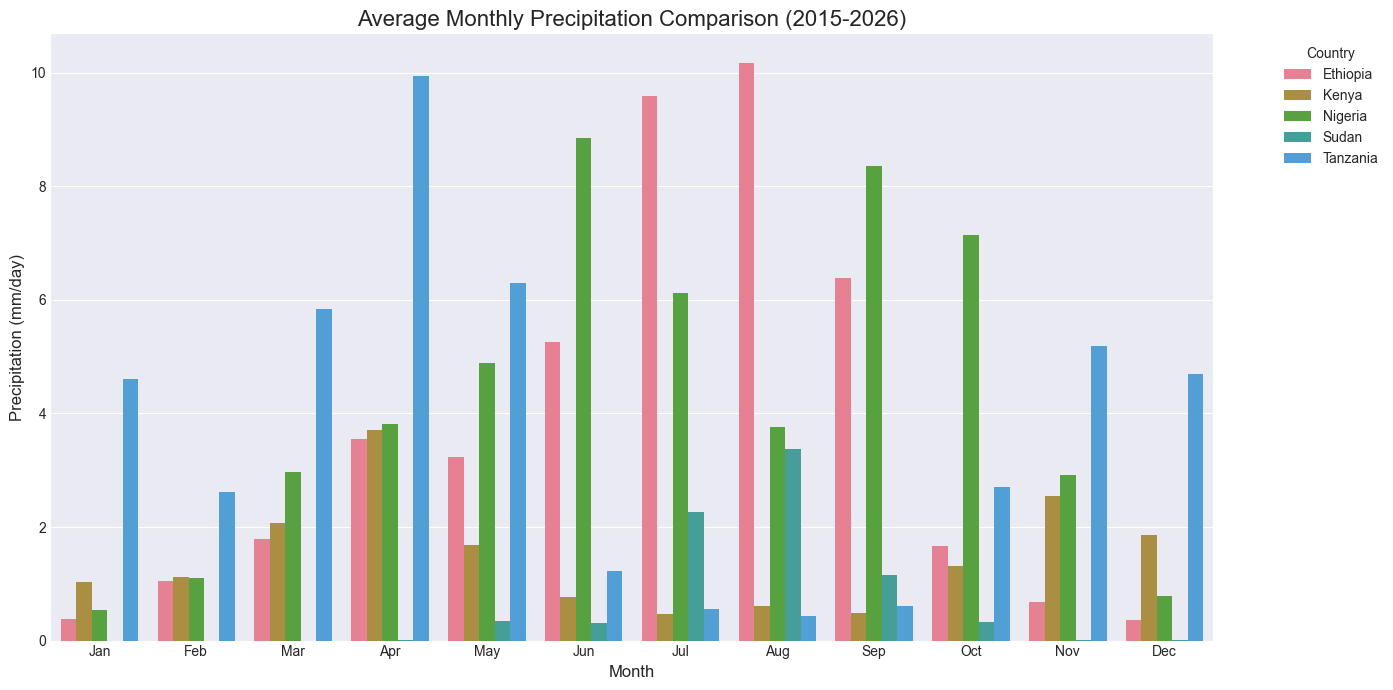

In [15]:
# Monthly average precipitation by country
monthly_precip = combined_df.groupby(['Country', 'Month'])['PRECTOTCORR'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=monthly_precip, x='Month', y='PRECTOTCORR', hue='Country')
plt.title('Average Monthly Precipitation Comparison (2015-2026)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Statistical Significance Testing
Using the Kruskal-Wallis H-test to identify significant differences between regions.

In [16]:
metrics = ['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M']
stats_results = []

for metric in metrics:
    # Group data by country for the metric
    groups = [combined_df[combined_df['Country'] == c][metric].dropna() for c in combined_df['Country'].unique()]
    
    # Kruskal-Wallis test
    h_stat, p_val = kruskal(*groups)
    
    stats_results.append({
        'Metric': metric,
        'H-Statistic': h_stat,
        'P-Value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

stats_df = pd.DataFrame(stats_results)
display(stats_df)

,Metric,H-Statistic,P-Value,Significant
0,T2M,15392.992232,0.0,Yes
1,PRECTOTCORR,4946.456777,0.0,Yes
2,RH2M,13626.322632,0.0,Yes
3,WS2M,9394.228819,0.0,Yes


## 4. Summary Table
Average climate metrics for each country.

In [17]:
summary_table = combined_df.groupby('Country')[['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M']].mean().round(2)
summary_table.columns = ['Avg Temp', 'Avg Precip', 'Avg Humidity', 'Avg Wind Speed']
display(summary_table.sort_values(by='Avg Temp', ascending=False))

,Avg Temp,Avg Precip,Avg Humidity,Avg Wind Speed
Country,,,,
Sudan,28.76,0.64,31.36,3.48
Tanzania,26.80,3.74,77.13,4.11
Nigeria,26.66,4.21,85.24,2.22
Kenya,20.43,1.47,65.85,3.06
Ethiopia,16.07,3.63,68.41,1.98
